# Latent ODEs for irregularly-sampled spirals

This notebook reproduces the toy spiral experiment from
[Rubanova, Chen & Duvenaud (NeurIPS 2019), "Latent ODEs for Irregularly-Sampled Time Series"](https://arxiv.org/abs/1907.03907) — but with the **ODE-RNN encoder replaced by a pure neural ODE**, in the spirit of [Kidger et al. (2020), "Neural CDEs"](https://arxiv.org/abs/2005.08926).

The model is a VAE on trajectories. For a single trajectory $\{(t_i, x_i)\}_{i=1}^N$ on $[t_0, t_N]$:

**Encoder (neural ODE).** Linearly interpolate the observations into a continuous path $\hat X(t)$. Integrate

$$\frac{dh}{dt} = f_\text{enc}\big(h(t),\, \hat X(t),\, t\big),\qquad h(t_0) = 0,$$

from $t_0$ to $t_N$ with `diffrax`, then map $h(t_N)$ to $(\mu, \log\sigma^2)$ of $q(z_0\mid x_{1:N})$. No GRU, no RNN cells — the observations enter the encoder only through the interpolated path.

**Latent dynamics (neural ODE).** $dz/dt = f_\text{lat}(z, t)$, integrated forward from $t_0$ saving at every requested time.

**Decoder.** A small MLP $z(t_i) \to \hat x_i$ with fixed Gaussian observation noise $\sigma_\text{obs}$.

**Loss.** Standard ELBO,

$$\mathcal{L} = \mathbb{E}_{q(z_0)}\!\Big[\sum_i \log p(x_i\mid z(t_i))\Big] - \mathrm{KL}\big(q(z_0)\,\|\,\mathcal{N}(0,I)\big).$$

We reuse `gauss_flows.DiffeqMLP` for both vector fields and the package's existing `pack_time_control` plumbing for the encoder's data-path conditioning.

In [1]:
from __future__ import annotations

import warnings

# tqdm.auto emits an IProgress warning whose path leaks the build env into
# committed notebook outputs; suppress before any (transitive) tqdm import.
warnings.filterwarnings(
    "ignore",
    message=r"IProgress not found\. Please update jupyter and ipywidgets\..*",
)

import diffrax
import equinox as eqx
import interpax
import jax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns

from gauss_flows import DiffeqMLP, pack_time_control


sns.set_theme(context="poster", style="whitegrid", palette="deep", font_scale=0.85)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.constrained_layout.use": True,
        "axes.grid.which": "both",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.5,
        "axes.titleweight": "semibold",
    }
)


def style_axes(ax, *, aspect=None):
    ax.minorticks_on()
    ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
    ax.grid(True, which="minor", linewidth=0.4, alpha=0.3)
    if aspect is not None:
        ax.set_aspect(aspect)
    return ax


palette = sns.color_palette("deep")

## 1. Synthetic spiral dataset

We follow Rubanova et al. §4.1: 2-D spirals with a random rotation, random direction (clockwise vs counter-clockwise), and a small additive Gaussian noise. Each trajectory is sampled densely on a common grid for reference, then **irregularly subsampled** to mimic real-world sensors.

In [2]:
N_TRAJ = 300
T_MAX = 5.0
N_DENSE = 100
N_OBS = 30
NOISE_STD = 0.05


def _sample_spiral(key, t):
    rot_key, dir_key = jr.split(key)
    theta = jr.uniform(rot_key, minval=0.0, maxval=2 * jnp.pi)
    direction = jr.choice(dir_key, jnp.array([-1.0, 1.0]))
    # Logarithmic spiral, parameterised so all trajectories share the same scale.
    r = 0.4 * t + 0.5
    angle = direction * (1.5 * t) + theta
    x = r * jnp.cos(angle)
    y = r * jnp.sin(angle)
    return jnp.stack([x, y], axis=-1)


def _irregular_subsample(key, t_dense, x_dense):
    # Pick N_OBS distinct indices, then sort them so timestamps are monotone.
    idx = jr.choice(key, t_dense.shape[0], shape=(N_OBS,), replace=False)
    idx = jnp.sort(idx)
    return t_dense[idx], x_dense[idx]


def make_dataset(key, n_traj):
    spiral_key, sample_key, noise_key = jr.split(key, 3)
    t_dense = jnp.linspace(0.0, T_MAX, N_DENSE)

    def per_traj(spiral_key, sample_key):
        x_clean = _sample_spiral(spiral_key, t_dense)
        t_obs, x_obs_clean = _irregular_subsample(sample_key, t_dense, x_clean)
        return x_clean, t_obs, x_obs_clean

    spiral_keys = jr.split(spiral_key, n_traj)
    sample_keys = jr.split(sample_key, n_traj)
    x_clean, t_obs, x_obs_clean = jax.vmap(per_traj)(spiral_keys, sample_keys)

    noise = NOISE_STD * jr.normal(noise_key, x_obs_clean.shape)
    x_obs = x_obs_clean + noise
    return t_dense, x_clean, t_obs, x_obs


t_dense, x_clean, t_obs, x_obs = make_dataset(jr.PRNGKey(0), N_TRAJ)
print(f"trajectories          : {N_TRAJ}")
print(f"dense grid points     : {N_DENSE}  on t in [0, {T_MAX}]")
print(f"observed per traj.    : {N_OBS}  (irregular, sorted)")
print(f"x_obs shape           : {x_obs.shape}")
print(f"t_obs shape           : {t_obs.shape}")

trajectories          : 300
dense grid points     : 100  on t in [0, 5.0]
observed per traj.    : 30  (irregular, sorted)
x_obs shape           : (300, 30, 2)
t_obs shape           : (300, 30)


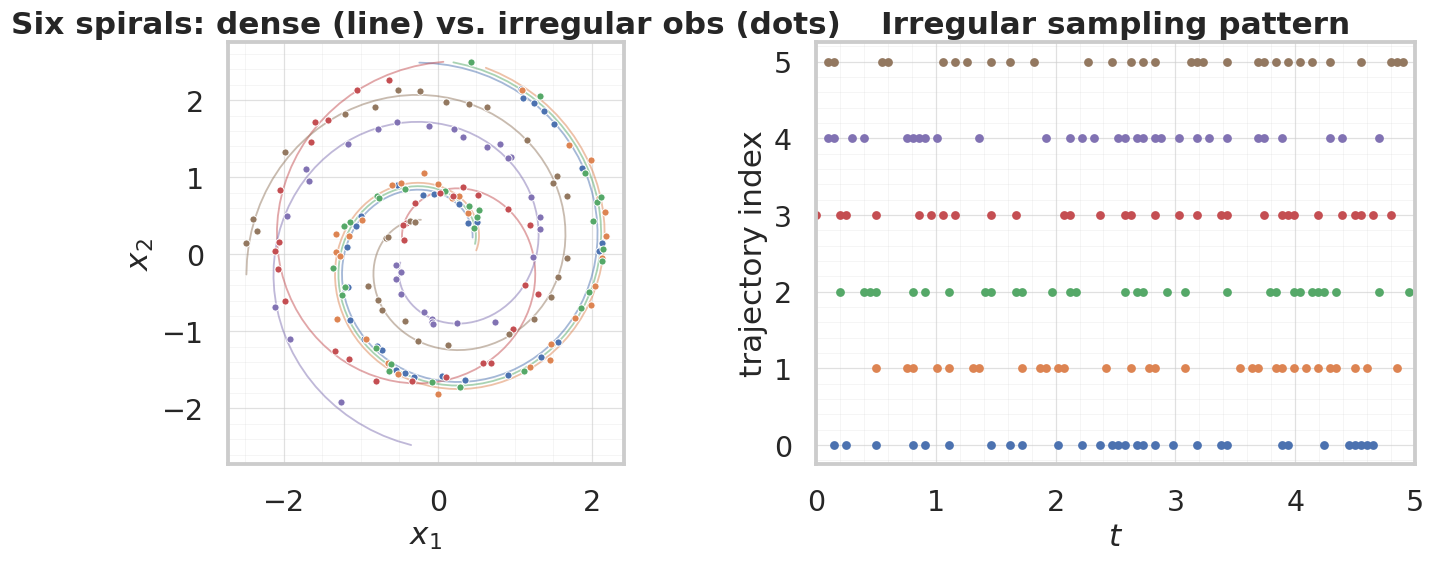

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax_xy, ax_t = axes
for k in range(6):
    ax_xy.plot(
        np.asarray(x_clean[k, :, 0]),
        np.asarray(x_clean[k, :, 1]),
        color=palette[k % len(palette)],
        alpha=0.5,
        linewidth=1.2,
    )
    ax_xy.scatter(
        np.asarray(x_obs[k, :, 0]),
        np.asarray(x_obs[k, :, 1]),
        s=22,
        color=palette[k % len(palette)],
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )
ax_xy.set_title("Six spirals: dense (line) vs. irregular obs (dots)")
ax_xy.set_xlabel("$x_1$")
ax_xy.set_ylabel("$x_2$")
style_axes(ax_xy, aspect="equal")

for k in range(6):
    ax_t.scatter(
        np.asarray(t_obs[k]),
        np.full(N_OBS, k),
        s=14,
        color=palette[k % len(palette)],
    )
ax_t.set_title("Irregular sampling pattern")
ax_t.set_xlabel("$t$")
ax_t.set_ylabel("trajectory index")
ax_t.set_xlim(0, T_MAX)
style_axes(ax_t)
plt.show()

## 2. Model

The encoder, latent dynamics, and decoder are all small `eqx.Module`s. The two vector fields are gauss_flows' `DiffeqMLP`. The encoder packages the interpolated observation $\hat X(t)$ as the **control** dimension of the time-control condition, so the same `DiffeqMLP` API used by FFJORD applies here unchanged.

**Why forward, not reversed?** The original Latent ODE encoder runs an ODE-RNN backward in time, a habit inherited from RNN seq2seq models that process tokens right-to-left. For a smooth ODE the path integral is symmetric in direction; running the encoder forward is the same model up to a reparametrization of $f_\text{enc}$, and one less thing to keep track of.

In [4]:
OBS_DIM = 2
LATENT_DIM = 4
ENC_HIDDEN = 25
DEC_HIDDEN = 20
SIGMA_OBS = 0.10


def _interp_path(t_query, t_obs_traj, x_obs_traj):
    # Linear interpolation of the observation path at scalar query time.
    return interpax.interp1d(
        jnp.atleast_1d(t_query),
        t_obs_traj,
        x_obs_traj,
        method="linear",
        extrap=True,
    )[0]


class LatentODEModel(eqx.Module):
    encoder_vf: DiffeqMLP
    enc_head: eqx.nn.Linear
    dynamics_vf: DiffeqMLP
    decoder: eqx.nn.MLP

    def __init__(self, key):
        k_enc, k_head, k_dyn, k_dec = jr.split(key, 4)
        self.encoder_vf = DiffeqMLP(
            k_enc,
            in_dim=ENC_HIDDEN,
            control_dim=OBS_DIM,
            hidden=(40, 40),
            activation=jnn.tanh,
        )
        self.enc_head = eqx.nn.Linear(ENC_HIDDEN, 2 * LATENT_DIM, key=k_head)
        self.dynamics_vf = DiffeqMLP(
            k_dyn,
            in_dim=LATENT_DIM,
            control_dim=0,
            hidden=(40, 40),
            activation=jnn.tanh,
        )
        self.decoder = eqx.nn.MLP(
            in_size=LATENT_DIM,
            out_size=OBS_DIM,
            width_size=DEC_HIDDEN,
            depth=2,
            activation=jnn.tanh,
            key=k_dec,
        )

    def encode(self, t_obs_traj, x_obs_traj):
        # Forward neural ODE on the data path: dh/dt = f_enc(h, X̂(t), t).
        def vf(t, h, args):
            t_traj, x_traj = args
            x_t = _interp_path(t, t_traj, x_traj)
            cond = pack_time_control(t, x_t)  # condition: (1 + obs_dim,)
            return self.encoder_vf(t, h, cond)

        sol = diffrax.diffeqsolve(
            diffrax.ODETerm(vf),
            solver=diffrax.Tsit5(),
            t0=t_obs_traj[0],
            t1=t_obs_traj[-1],
            dt0=0.05,
            y0=jnp.zeros(ENC_HIDDEN),
            args=(t_obs_traj, x_obs_traj),
            saveat=diffrax.SaveAt(t1=True),
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-4),
            adjoint=diffrax.RecursiveCheckpointAdjoint(),
            max_steps=4096,
        )
        h_final = sol.ys[-1]
        params = self.enc_head(h_final)  # (2 * LATENT_DIM,)
        mu, log_var = jnp.split(params, 2, axis=-1)
        # Clamp log_var into a stable range; standard VAE trick.
        log_var = jnp.clip(log_var, -8.0, 4.0)
        return mu, log_var

    def decode(self, z0, times):
        # Forward neural ODE on z, save at every requested time.
        def vf(t, z, args):
            return self.dynamics_vf(t, z, None)

        sol = diffrax.diffeqsolve(
            diffrax.ODETerm(vf),
            solver=diffrax.Tsit5(),
            t0=times[0],
            t1=times[-1],
            dt0=0.05,
            y0=z0,
            saveat=diffrax.SaveAt(ts=times),
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-4),
            adjoint=diffrax.RecursiveCheckpointAdjoint(),
            max_steps=4096,
        )
        z_traj = sol.ys  # (T, LATENT_DIM)
        x_hat = jax.vmap(self.decoder)(z_traj)  # (T, OBS_DIM)
        return z_traj, x_hat

    def elbo(self, key, t_obs_traj, x_obs_traj):
        mu, log_var = self.encode(t_obs_traj, x_obs_traj)
        # Reparametrised sample.
        eps = jr.normal(key, mu.shape)
        z0 = mu + jnp.exp(0.5 * log_var) * eps
        # Decode at observed times: t_obs_traj is already sorted.
        _, x_hat = self.decode(z0, t_obs_traj)
        # Gaussian log-likelihood with fixed sigma.
        recon = jnp.sum(
            -0.5 * jnp.square((x_obs_traj - x_hat) / SIGMA_OBS)
            - jnp.log(SIGMA_OBS)
            - 0.5 * jnp.log(2 * jnp.pi)
        )
        # KL(q(z0) || N(0,I)) for diagonal Gaussians.
        kl = 0.5 * jnp.sum(jnp.exp(log_var) + jnp.square(mu) - 1.0 - log_var)
        return recon - kl, recon, kl


key = jr.key(0)
model_key, train_key, eval_key = jr.split(key, 3)
model = LatentODEModel(model_key)

n_params = sum(
    int(np.prod(p.shape))
    for p in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array))
)
print(f"latent dim            : {LATENT_DIM}")
print(f"encoder hidden        : {ENC_HIDDEN}")
print(f"decoder hidden        : {DEC_HIDDEN}")
print(f"obs noise sigma       : {SIGMA_OBS}")
print(f"trainable parameters  : {n_params}")

latent dim            : 4
encoder hidden        : 25
decoder hidden        : 20
obs noise sigma       : 0.1
trainable parameters  : 6679


## 3. Training

Per gradient step we

1. encode each trajectory with one forward neural ODE solve;
2. sample $z_0$ via the reparametrisation trick;
3. decode by integrating the latent ODE forward, saving at every observed time;
4. compute Gaussian log-likelihood + closed-form KL.

Two ODE solves per trajectory per step makes this noticeably more expensive than the FFJORD-2D notebook. We keep the run short (250 epochs, batch 50) so it fits in a notebook; longer training tightens the reconstructions.

In [5]:
N_EPOCHS = 250
BATCH_SIZE = 50
LR = 3e-3


@eqx.filter_jit
def loss_fn(model, key, t_batch, x_batch):
    keys = jr.split(key, t_batch.shape[0])
    elbos, recons, kls = jax.vmap(model.elbo)(keys, t_batch, x_batch)
    elbo = jnp.mean(elbos)
    return -elbo, (jnp.mean(recons), jnp.mean(kls))


@eqx.filter_jit
def step(model, opt_state, key, t_batch, x_batch):
    (loss, (recon, kl)), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
        model, key, t_batch, x_batch
    )
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss, recon, kl


optimizer = optax.chain(
    optax.clip_by_global_norm(5.0),
    optax.adam(LR),
)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

n_train = N_TRAJ
losses, recons, kls = [], [], []
for epoch in range(N_EPOCHS):
    train_key, perm_key, batch_key = jr.split(train_key, 3)
    perm = jr.permutation(perm_key, n_train)
    t_shuf = t_obs[perm]
    x_shuf = x_obs[perm]
    epoch_loss, epoch_recon, epoch_kl = 0.0, 0.0, 0.0
    n_batches = n_train // BATCH_SIZE
    for b in range(n_batches):
        sl = slice(b * BATCH_SIZE, (b + 1) * BATCH_SIZE)
        batch_key, sub = jr.split(batch_key)
        model, opt_state, loss, recon, kl = step(
            model, opt_state, sub, t_shuf[sl], x_shuf[sl]
        )
        epoch_loss += float(loss)
        epoch_recon += float(recon)
        epoch_kl += float(kl)
    losses.append(epoch_loss / n_batches)
    recons.append(epoch_recon / n_batches)
    kls.append(epoch_kl / n_batches)
    if epoch == 0 or (epoch + 1) % 25 == 0:
        print(
            f"epoch {epoch + 1:>4d}  loss {losses[-1]:>9.3f}  "
            f"recon {recons[-1]:>9.3f}  KL {kls[-1]:>7.3f}"
        )

epoch    1  loss  3910.698  recon -3907.917  KL   2.782


epoch   25  loss  2352.796  recon -2317.883  KL  34.913


epoch   50  loss  1139.336  recon -1097.639  KL  41.698


epoch   75  loss   259.363  recon  -223.583  KL  35.781


epoch  100  loss   202.276  recon  -167.079  KL  35.197


...

epoch  150  loss    73.713  recon   -36.156  KL  37.557


epoch  175  loss   117.078  recon   -83.348  KL  33.730


epoch  200  loss    84.946  recon   -52.108  KL  32.837


epoch  225  loss    66.039  recon   -34.391  KL  31.648


epoch  250  loss    55.007  recon   -24.685  KL  30.322


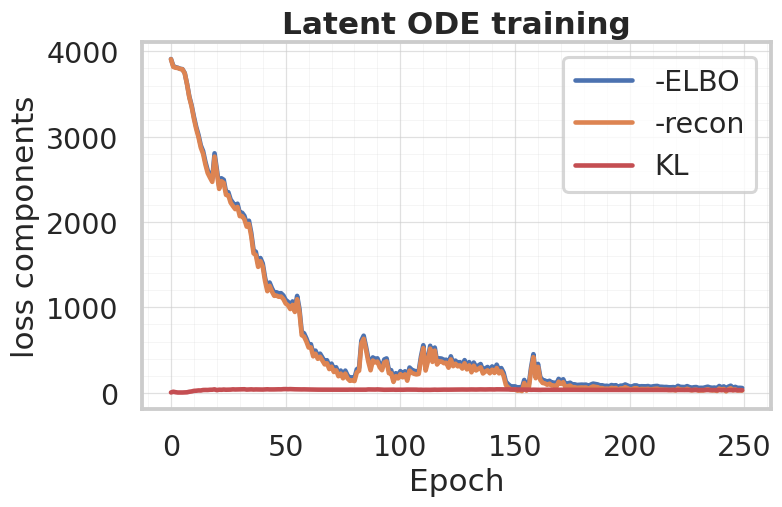

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
epochs = np.arange(len(losses))
ax.plot(epochs, losses, color=palette[0], label="-ELBO")
ax.plot(epochs, [-r for r in recons], color=palette[1], label="-recon")
ax.plot(epochs, kls, color=palette[3], label="KL")
ax.set_xlabel("Epoch")
ax.set_ylabel("loss components")
ax.set_title("Latent ODE training")
ax.legend()
style_axes(ax)
plt.show()

## 4. Reconstruction on irregular observations

For each held-out trajectory we encode the irregular observations, then decode on the **dense** time grid. The smooth ODE-driven latent gives a clean spiral that passes through the noisy observations.

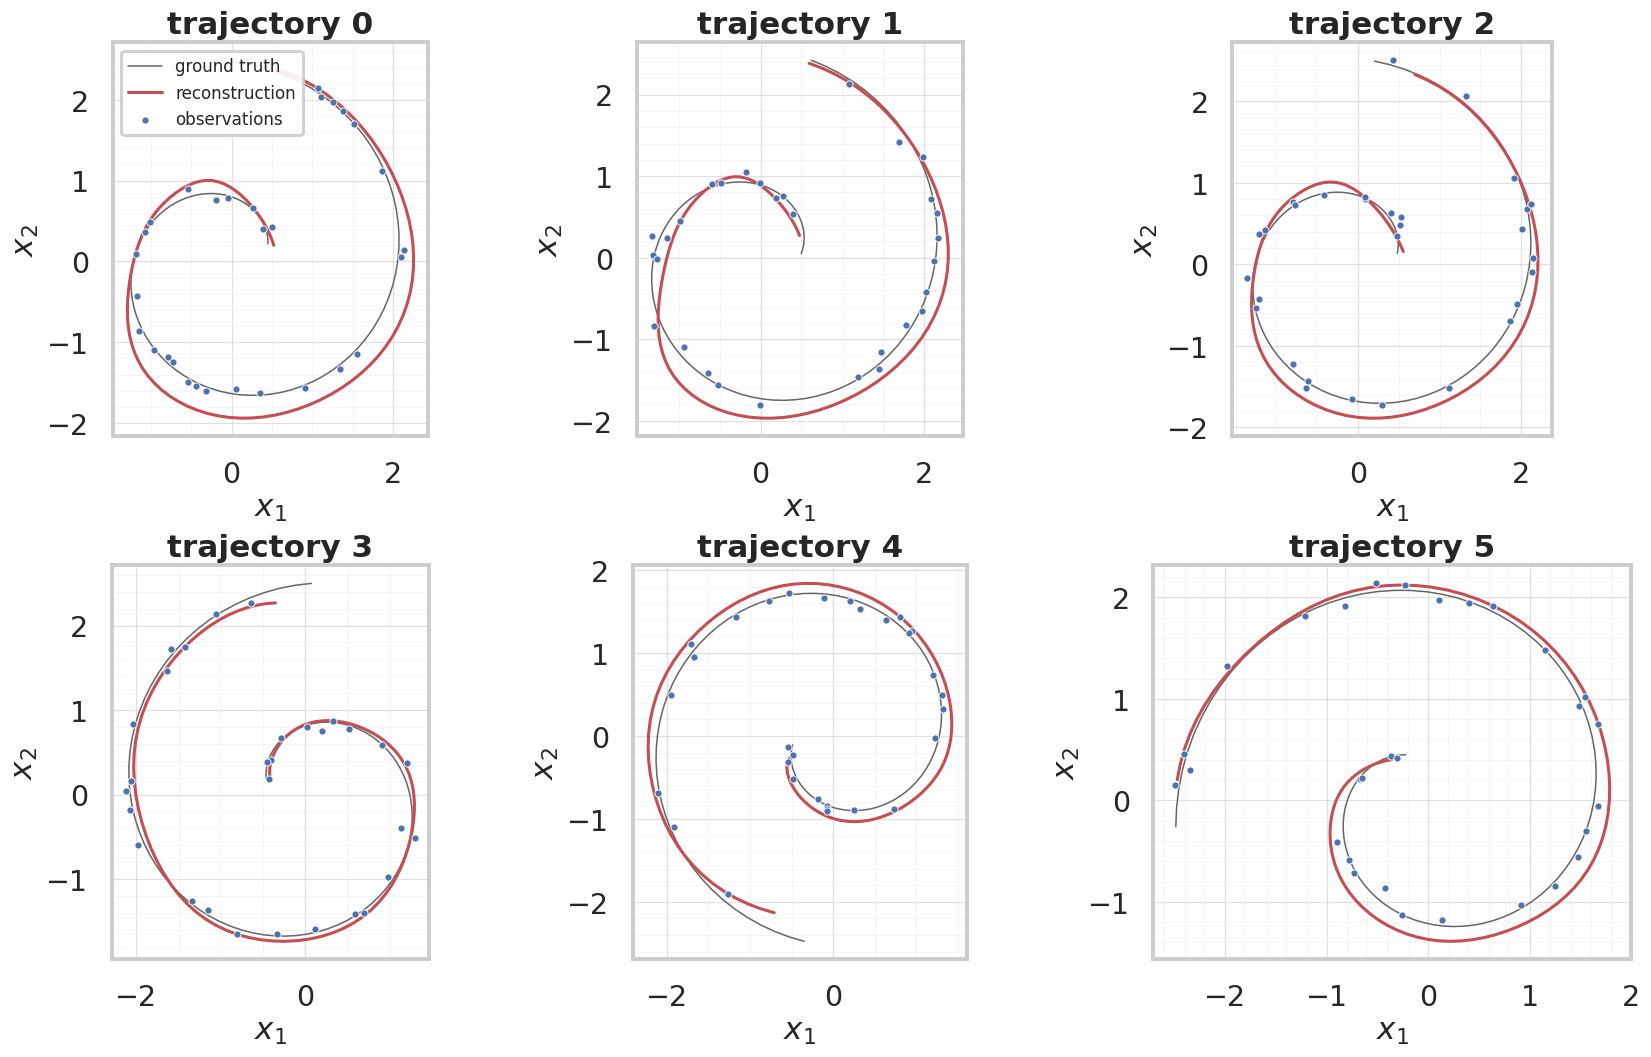

In [7]:
N_SHOW = 6
recon_keys = jr.split(eval_key, N_SHOW)


@eqx.filter_jit
def reconstruct(model, key, t_obs_traj, x_obs_traj, t_target):
    mu, log_var = model.encode(t_obs_traj, x_obs_traj)
    eps = jr.normal(key, mu.shape)
    z0 = mu + jnp.exp(0.5 * log_var) * eps
    _, x_hat = model.decode(z0, t_target)
    return x_hat, mu


fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
for k, ax in enumerate(axes.flat):
    x_hat, _ = reconstruct(model, recon_keys[k], t_obs[k], x_obs[k], t_dense)
    ax.plot(
        np.asarray(x_clean[k, :, 0]),
        np.asarray(x_clean[k, :, 1]),
        color="0.4",
        linewidth=1.0,
        label="ground truth",
    )
    ax.plot(
        np.asarray(x_hat[:, 0]),
        np.asarray(x_hat[:, 1]),
        color=palette[3],
        linewidth=2.0,
        label="reconstruction",
    )
    ax.scatter(
        np.asarray(x_obs[k, :, 0]),
        np.asarray(x_obs[k, :, 1]),
        s=22,
        color=palette[0],
        edgecolor="white",
        linewidth=0.6,
        label="observations",
        zorder=3,
    )
    ax.set_title(f"trajectory {k}")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    style_axes(ax, aspect="equal")
    if k == 0:
        ax.legend(loc="upper left", framealpha=0.9, fontsize=11)
plt.show()

## 5. Extrapolation

Latent ODEs extrapolate naturally: encode using only observations on $[0, T/2]$, then integrate the latent ODE all the way to $T$. The model has never seen the target times during this trajectory's encoding, but the latent dynamics are time-translation-equivariant only insofar as the training data taught them — so this is a real generalisation test.

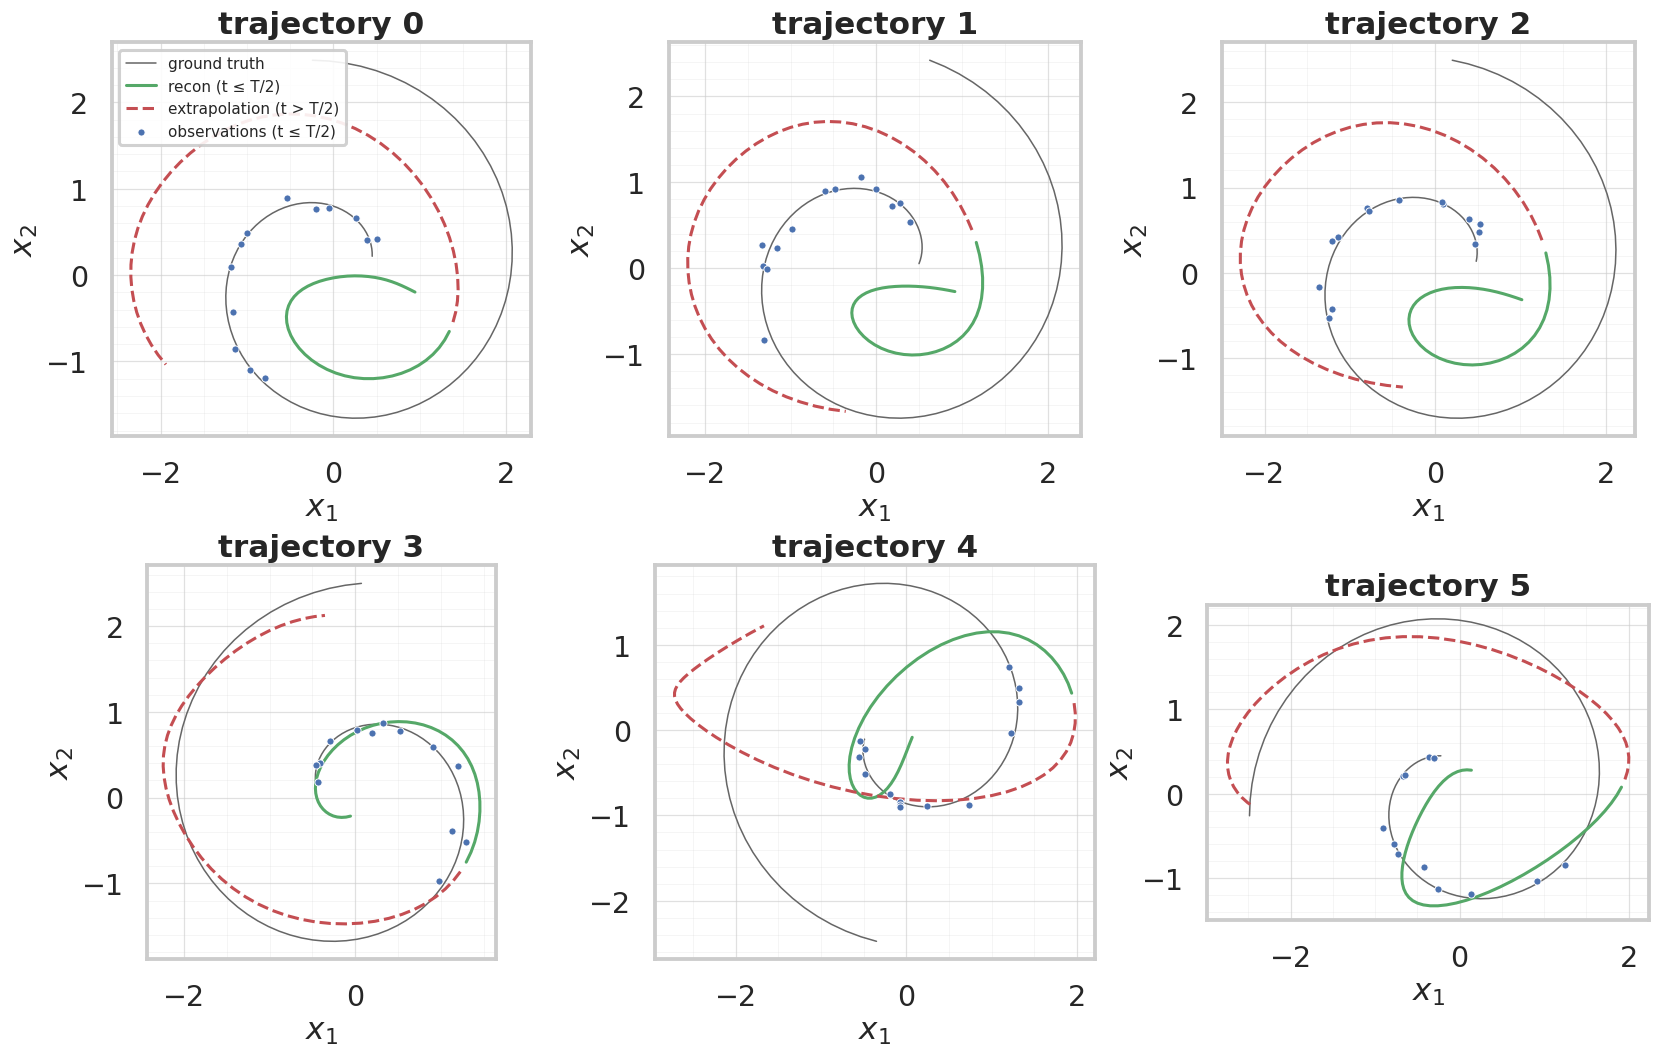

In [8]:
T_HALF = T_MAX / 2.0


def split_trajectory(t_obs_traj, x_obs_traj):
    # Mask to the first half of t and pad-by-repeat to keep static shapes.
    mask = t_obs_traj <= T_HALF
    n_keep = int(jnp.sum(mask))
    return t_obs_traj[:n_keep], x_obs_traj[:n_keep]


fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
for k, ax in enumerate(axes.flat):
    t_half, x_half = split_trajectory(t_obs[k], x_obs[k])
    if t_half.shape[0] < 4:
        ax.set_visible(False)
        continue
    mu, log_var = model.encode(t_half, x_half)
    z0 = mu  # use the mean for a clean visualisation
    _, x_hat = model.decode(z0, t_dense)
    ax.plot(
        np.asarray(x_clean[k, :, 0]),
        np.asarray(x_clean[k, :, 1]),
        color="0.4",
        linewidth=1.0,
        label="ground truth",
    )
    half_mask_dense = np.asarray(t_dense <= T_HALF)
    ax.plot(
        np.asarray(x_hat[half_mask_dense, 0]),
        np.asarray(x_hat[half_mask_dense, 1]),
        color=palette[2],
        linewidth=2.0,
        label="recon (t ≤ T/2)",
    )
    ax.plot(
        np.asarray(x_hat[~half_mask_dense, 0]),
        np.asarray(x_hat[~half_mask_dense, 1]),
        color=palette[3],
        linewidth=2.0,
        linestyle="--",
        label="extrapolation (t > T/2)",
    )
    ax.scatter(
        np.asarray(x_half[:, 0]),
        np.asarray(x_half[:, 1]),
        s=22,
        color=palette[0],
        edgecolor="white",
        linewidth=0.6,
        label="observations (t ≤ T/2)",
        zorder=3,
    )
    ax.set_title(f"trajectory {k}")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    style_axes(ax, aspect="equal")
    if k == 0:
        ax.legend(loc="upper left", framealpha=0.9, fontsize=10)
plt.show()

## 6. Notes

- **Pure-ODE encoder cost.** Two adaptive ODE solves per trajectory per step (encoder forward + decoder forward). On CPU each epoch in this notebook is a few seconds; with the original ODE-RNN encoder you avoid the encoder ODE entirely and replace it with cheap GRU updates. Pure ODE buys uniformity, not speed.
- **Path interpolation choice.** We use linear interpolation for $\hat X(t)$. Kidger et al. argue for natural cubic splines because they give a smooth derivative for the controlled equation; for a 2-D toy with 30 obs the difference is small. To switch, replace `method="linear"` with `method="cubic2"` in `_interp_path` (cost: a one-time spline fit per trajectory).
- **Forward vs. reversed encoder.** The original paper runs the encoder backwards (`t_N → t_0`), inherited from RNN seq2seq habits. For an ODE the integral path is the same up to a sign of $f_\text{enc}$; we run forward for clarity.
- **Extrapolation regime.** The latent dynamics are autonomous (unconditional on observations beyond $z_0$), so extrapolation is only as good as the prior over $z_0$ allows the dynamics to capture the spiral family. With more training and a richer dynamics MLP the extrapolated arms tighten visibly.